# Wind Farm Layout Optimisation using Genetic Algorithm

This notebook implements a Genetic Algorithm (GA) to maximise the Annual Energy Production (AEP) of a 50‑turbine wind farm.
Constraints: boundary clearance 50 m, minimum turbine spacing 400 m.
The GA uses real‑valued encoding, tournament selection, SBX crossover, polynomial mutation, and a dynamic penalty approach.

In [1]:
# Imports and setup (same as original notebook)
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import time
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.getcwd())
from Farm_Evaluator_Vec import (
    getTurbLoc, loadPowerCurve, binWindResourceData,
    preProcessing, getAEP, checkConstraints
)

# Set random seed for reproducibility
np.random.seed(42)

# Load wind data and pre‑compute constants
DATA_DIR = 'Wind_Data'
combined_wind_path = "combined_wind_data_all_years.csv"

if not os.path.exists(combined_wind_path):
    wind_files = [os.path.join(DATA_DIR, f'wind_data_{year}.csv') for year in [2007,2008,2009,2013,2014,2015,2017]]
    dfs = [pd.read_csv(f) for f in wind_files]
    combined = pd.concat(dfs)
    combined['date'] = pd.to_datetime(combined['date'])
    combined.sort_values('date', inplace=True)
    combined.to_csv(combined_wind_path, index=False)

wind_inst_freq = binWindResourceData(combined_wind_path)
power_curve_df = pd.read_csv('power_curve.csv')
power_curve_arr = power_curve_df.to_numpy(dtype=np.float32)
turb_rad = 50.0

def compute_true_aep(coords):
    """Wrapper for official AEP computation."""
    if len(coords) == 0:
        return 0.0
    coords_arr = np.array(coords, dtype=np.float32)
    n_turbs = len(coords_arr)
    n_wind_inst, cos_dir, sin_dir, wind_sped_stacked, C_t = preProcessing(power_curve_arr, n_turbs)
    aep = getAEP(turb_rad, coords_arr, power_curve_arr, wind_inst_freq,
                 n_wind_inst, cos_dir, sin_dir, wind_sped_stacked, C_t)
    return aep

print("True AEP evaluator ready.")

True AEP evaluator ready.


In [2]:
#  Helper functions for constraint handling and random valid layout generation
def is_valid_layout(coords, min_dist=400, bounds=(50,3950)):
    """Check if layout satisfies all constraints."""
    coords = np.array(coords)
    # Boundary
    if np.any(coords[:,0] < bounds[0]) or np.any(coords[:,0] > bounds[1]) or \
       np.any(coords[:,1] < bounds[0]) or np.any(coords[:,1] > bounds[1]):
        return False
    # Proximity
    if len(coords) > 1:
        dists = pdist(coords)
        if np.any(dists < min_dist):
            return False
    return True

def generate_random_valid_layout(n_turbs=50, min_dist=400, max_attempts=5000):
    """Generate a random layout that satisfies constraints (sequential placement)."""
    coords = []
    for _ in range(n_turbs):
        placed = False
        for _ in range(max_attempts):
            x = np.random.uniform(50, 3950)
            y = np.random.uniform(50, 3950)
            new_point = np.array([x, y])
            if len(coords) == 0:
                coords.append(new_point)
                placed = True
                break
            dists = np.linalg.norm(np.array(coords) - new_point, axis=1)
            if np.min(dists) >= min_dist:
                coords.append(new_point)
                placed = True
                break
        if not placed:
            # Restart if cannot place all turbines
            return generate_random_valid_layout(n_turbs, min_dist, max_attempts)
    return np.array(coords, dtype=np.float32)

def penalty(coords, min_dist=400, bounds=(50,3950), penalty_weight=1000.0):
    """Calculate penalty for constraint violations.
       Returns a value that is added to the negative fitness (since we maximize)."""
    coords = np.array(coords)
    penalty_val = 0.0
    # Boundary penalty
    for i in range(2):
        below = np.maximum(bounds[0] - coords[:,i], 0)
        above = np.maximum(coords[:,i] - bounds[1], 0)
        penalty_val += np.sum(below**2) + np.sum(above**2)
    # Proximity penalty
    if len(coords) > 1:
        dists = pdist(coords)
        violations = np.maximum(min_dist - dists, 0)
        penalty_val += np.sum(violations**2)
    return penalty_weight * penalty_val

In [3]:
# Genetic Algorithm components
def initialize_population(pop_size):
    """Create initial population of random valid layouts."""
    population = []
    for _ in range(pop_size):
        layout = generate_random_valid_layout()
        population.append(layout.flatten())  # flatten to 1D vector
    return np.array(population)

def evaluate_fitness(individual, penalty_weight=1000.0):
    """Compute fitness = AEP - penalty."""
    coords = individual.reshape(-1, 2)
    aep = compute_true_aep(coords)
    pen = penalty(coords, penalty_weight=penalty_weight)
    return aep - pen

def tournament_selection(population, fitness, k=3):
    """Select one individual using tournament selection."""
    idx = np.random.choice(len(population), k, replace=False)
    best_idx = idx[np.argmax(fitness[idx])]
    return population[best_idx].copy()

def sbx_crossover(parent1, parent2, eta=20, prob_cross=0.9):
    """Simulated Binary Crossover (SBX) for real‑valued vectors."""
    if np.random.rand() > prob_cross:
        return parent1.copy(), parent2.copy()
    child1, child2 = parent1.copy(), parent2.copy()
    for i in range(len(parent1)):
        if np.random.rand() > 0.5:
            u = np.random.rand()
            if u <= 0.5:
                beta = (2*u)**(1/(eta+1))
            else:
                beta = (1/(2*(1-u)))**(1/(eta+1))
            child1[i] = 0.5 * ((1+beta)*parent1[i] + (1-beta)*parent2[i])
            child2[i] = 0.5 * ((1-beta)*parent1[i] + (1+beta)*parent2[i])
    return child1, child2

def polynomial_mutation(individual, prob_mut=0.1, eta=20, bounds=(50,3950)):
    """Polynomial mutation."""
    mutated = individual.copy()
    for i in range(len(individual)):
        if np.random.rand() < prob_mut:
            u = np.random.rand()
            delta = 0.0
            if u <= 0.5:
                delta = (2*u)**(1/(eta+1)) - 1
            else:
                delta = 1 - (2*(1-u))**(1/(eta+1))
            mutated[i] += delta * (bounds[1] - bounds[0]) * 0.1  # mutation step size
            mutated[i] = np.clip(mutated[i], bounds[0], bounds[1])
    return mutated

def repair_individual(individual, min_dist=400, bounds=(50,3950), max_attempts=100):
    """Repair an individual that may violate constraints by moving problematic turbines slightly."""
    coords = individual.reshape(-1, 2)
    # First clip to bounds
    coords = np.clip(coords, bounds[0], bounds[1])
    # Then handle proximity violations greedily
    for i in range(len(coords)):
        for _ in range(max_attempts):
            # Check distances to all others
            others = np.delete(coords, i, axis=0)
            dists = np.linalg.norm(others - coords[i], axis=1)
            if len(dists) == 0 or np.min(dists) >= min_dist:
                break
            # Move away from the closest turbine
            closest_idx = np.argmin(dists)
            direction = coords[i] - others[closest_idx]
            norm = np.linalg.norm(direction)
            if norm > 0:
                direction /= norm
            coords[i] += direction * (min_dist - dists[closest_idx] + 5)
            coords[i] = np.clip(coords[i], bounds[0], bounds[1])
    return coords.flatten()

In [4]:
# Main GA loop
POP_SIZE = 100
N_GENERATIONS = 200
ELITE_SIZE = 2
PENALTY_WEIGHT_START = 100.0
PENALTY_WEIGHT_END = 10000.0

print("Initializing population...")
population = initialize_population(POP_SIZE)
best_fitness_history = []
best_individual = None
best_aep = -np.inf

for gen in range(N_GENERATIONS):
    # Gradually increase penalty weight
    penalty_weight = PENALTY_WEIGHT_START + (PENALTY_WEIGHT_END - PENALTY_WEIGHT_START) * (gen / N_GENERATIONS)
    
    # Evaluate fitness
    fitness = np.array([evaluate_fitness(ind, penalty_weight) for ind in population])
    
    # Track best
    current_best_idx = np.argmax(fitness)
    current_best_flat = population[current_best_idx]
    current_best_coords = current_best_flat.reshape(-1, 2)
    current_best_aep = compute_true_aep(current_best_coords)
    if current_best_aep > best_aep:
        best_aep = current_best_aep
        best_individual = current_best_flat.copy()
    best_fitness_history.append(best_aep)
    
    if gen % 20 == 0:
        print(f"Gen {gen:3d} | Best AEP: {best_aep:.3f} GWh | Current best AEP: {current_best_aep:.3f} GWh")
    
    # Create next generation
    new_population = []
    # Elitism
    elite_indices = np.argsort(fitness)[-ELITE_SIZE:]
    for idx in elite_indices:
        new_population.append(population[idx].copy())
    
    # Generate offspring
    while len(new_population) < POP_SIZE:
        parent1 = tournament_selection(population, fitness)
        parent2 = tournament_selection(population, fitness)
        child1, child2 = sbx_crossover(parent1, parent2)
        child1 = polynomial_mutation(child1)
        child2 = polynomial_mutation(child2)
        child1 = repair_individual(child1)
        child2 = repair_individual(child2)
        new_population.append(child1)
        if len(new_population) < POP_SIZE:
            new_population.append(child2)
    population = np.array(new_population)

print(f"\nGA finished. Best AEP found: {best_aep:.3f} GWh")
best_coords = best_individual.reshape(-1, 2)

Initializing population...
Gen   0 | Best AEP: 507.914 GWh | Current best AEP: 507.914 GWh
Gen  20 | Best AEP: 511.612 GWh | Current best AEP: 511.612 GWh
Gen  40 | Best AEP: 512.407 GWh | Current best AEP: 512.407 GWh
Gen  60 | Best AEP: 512.751 GWh | Current best AEP: 512.751 GWh
Gen  80 | Best AEP: 513.248 GWh | Current best AEP: 513.248 GWh
Gen 100 | Best AEP: 513.379 GWh | Current best AEP: 513.379 GWh
Gen 120 | Best AEP: 513.387 GWh | Current best AEP: 513.387 GWh
Gen 140 | Best AEP: 513.387 GWh | Current best AEP: 513.387 GWh
Gen 160 | Best AEP: 513.402 GWh | Current best AEP: 513.402 GWh
Gen 180 | Best AEP: 513.607 GWh | Current best AEP: 513.607 GWh

GA finished. Best AEP found: 513.639 GWh


In [9]:
best_coords

array([[2652.4722  , 3306.202   ],
       [2707.8916  , 1676.5961  ],
       [2562.1714  , 1068.3721  ],
       [1324.51    , 3191.1887  ],
       [1800.5089  , 3102.4849  ],
       [3160.9304  , 3385.48    ],
       [3462.778   , 1650.6829  ],
       [1332.0884  , 2302.1035  ],
       [3032.8777  , 2737.176   ],
       [1519.2644  ,  763.74054 ],
       [ 656.34607 ,   50.000008],
       [1651.711   , 1336.5803  ],
       [2858.511   ,  604.78394 ],
       [1905.1354  ,   50.000004],
       [2068.166   , 3808.5845  ],
       [ 139.62744 , 1527.2655  ],
       [1155.0762  , 3582.5764  ],
       [ 189.9516  , 3607.5063  ],
       [3921.2761  , 1156.0958  ],
       [2076.5752  ,  457.87216 ],
       [2179.585   , 2161.584   ],
       [1068.9642  ,  844.86755 ],
       [2195.6458  , 1399.655   ],
       [1746.701   , 2499.3398  ],
       [3949.9998  , 3438.9377  ],
       [3602.9521  , 2834.3027  ],
       [ 615.37085 , 3155.4058  ],
       [3848.847   ,  712.41583 ],
       [1750.6554  ,

In [13]:
def refine(selected, max_passes=10, step=20, range_=200):
    """
    For each turbine, try moving it within a square of side 2*range_ (step size `step`)
    while keeping constraints. Repeat for max_passes.
    """
    selected = list(selected)
    improved = True
    
    for _ in range(max_passes):
        if not improved:
            break
        improved = False
        
        for idx in range(len(selected)):
            best_aep = compute_true_aep(selected)
            best_coord = selected[idx]
            x0, y0 = selected[idx]
            
            # Candidate moves: all integer multiples of step within [-range_, range_]
            moves = [d for d in range(-range_, range_+1, step)]
            
            for dx in moves:
                for dy in moves:
                    if dx == 0 and dy == 0:
                        continue
                        
                    nx = x0 + dx
                    ny = y0 + dy
                    
                    # Boundary check (clearance 50 m)
                    if nx < 50 or nx > 3950 or ny < 50 or ny > 3950:
                        continue
                        
                    # Check distance to other turbines
                    other_coords = selected[:idx] + selected[idx+1:]
                    if any(np.linalg.norm(np.array([nx, ny]) - np.array(s)) < 400 for s in other_coords):
                        continue
                        
                    new_coords = other_coords + [(nx, ny)]
                    new_aep = compute_true_aep(new_coords)
                    
                    if new_aep > best_aep:
                        best_aep = new_aep
                        best_coord = (nx, ny)
                        improved = True
                        
            # THE FIX: Force both to be tuples to safely compare without NumPy ambiguity
            if tuple(best_coord) != tuple(selected[idx]):
                selected[idx] = best_coord
                print(f"Moved turbine {idx+1} to {best_coord} -> AEP = {best_aep:.4f} GWh")
                
    return selected

print("\nStarting local refinement...")
refined  = refine(best_coords, max_passes=10, step=20, range_=200)
final_aep = compute_true_aep(refined)
print(f"\nRefinement finished. Final AEP = {final_aep:.4f} GWh")


Starting local refinement...
Moved turbine 2 to (np.float32(2647.8916), np.float32(1756.5961)) -> AEP = 513.9636 GWh
Moved turbine 3 to (np.float32(2482.1714), np.float32(928.3721)) -> AEP = 514.2799 GWh
Moved turbine 4 to (np.float32(1304.51), np.float32(3171.1887)) -> AEP = 514.3383 GWh
Moved turbine 5 to (np.float32(1760.5089), np.float32(3022.4849)) -> AEP = 514.5287 GWh
Moved turbine 6 to (np.float32(3120.9304), np.float32(3465.48)) -> AEP = 514.6790 GWh
Moved turbine 7 to (np.float32(3662.778), np.float32(1790.6829)) -> AEP = 514.8157 GWh
Moved turbine 8 to (np.float32(1332.0884), np.float32(2322.1035)) -> AEP = 514.8192 GWh
Moved turbine 9 to (np.float32(3132.8777), np.float32(2917.176)) -> AEP = 514.9852 GWh
Moved turbine 10 to (np.float32(1539.2644), np.float32(763.74054)) -> AEP = 515.0377 GWh
Moved turbine 12 to (np.float32(1851.711), np.float32(1136.5803)) -> AEP = 515.1111 GWh
Moved turbine 13 to (np.float32(2958.511), np.float32(504.78394)) -> AEP = 515.2463 GWh
Moved tu

In [14]:
# Baseline from problem statement
baseline_aep = 526.4387
print(f"Baseline greedy+refinement AEP: {baseline_aep:.3f} GWh")
print(f"Improvement: {final_aep - baseline_aep:+.3f} GWh")

Baseline greedy+refinement AEP: 526.439 GWh
Improvement: -2.764 GWh


In [15]:
# Save final layout
df_out = pd.DataFrame(refined, columns=['x', 'y'])
df_out.to_csv('turbine_layout_ga_optimised.csv', index=False)
print("Final layout saved to 'turbine_layout_ga_optimised.csv'") 

Final layout saved to 'turbine_layout_ga_optimised.csv'


In [26]:
refined_cords = pd.DataFrame(refined)
refined_cords

,0,1
0,2512.472168,3566.201904
1,2687.891602,1676.596069
2,2582.171387,908.372070
3,1064.510010,3331.188721
4,1620.508911,3102.484863
5,3040.930420,3485.479980
6,3602.778076,1710.682861
7,1172.088379,2402.103516
8,3132.877686,3017.176025
9,1539.264404,543.740540


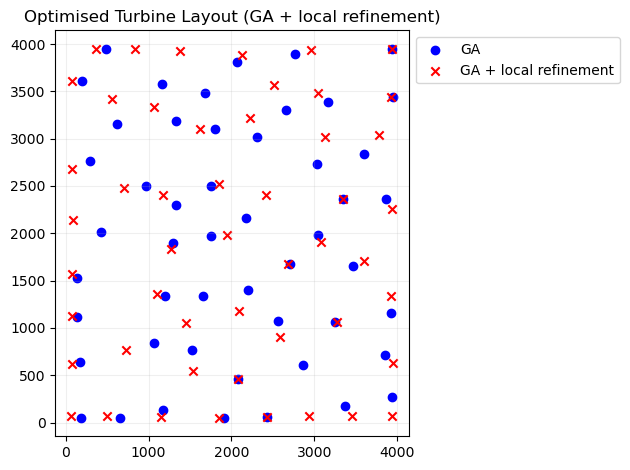

In [27]:
x = best_coords[:, 0]
y = best_coords[:, 1]
x2 = refined_cords[0]
y2 =refined_cords[1]

plt.scatter(x, y, color='blue', marker='o', label='GA')
plt.scatter(x2, y2, color='red', marker='x', label='GA + local refinement')

plt.title("Optimised Turbine Layout (GA + local refinement)")                                                                                                                                                                                                                                                                                                                                                       

plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(alpha = 0.2)
plt.tight_layout()

plt.show()


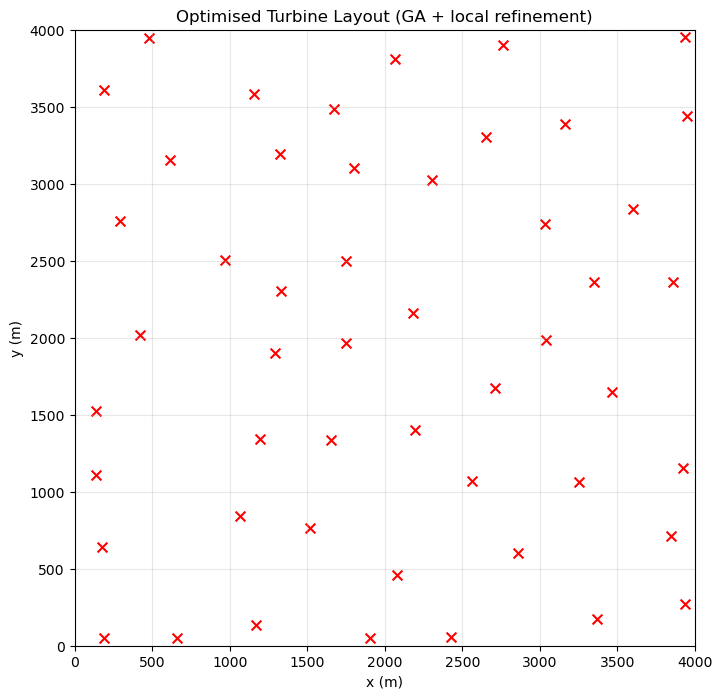

In [28]:
# Plot
plt.figure(figsize=(8,8))
plt.scatter(best_coords[:,0], best_coords[:,1], c='red', marker='x', s=50)
plt.xlim(0,4000)
plt.ylim(0,4000)
plt.xlabel('x (m)') 
plt.ylabel('y (m)')
plt.title('Optimised Turbine Layout (GA + local refinement)')
plt.grid(alpha=0.3)
plt.show()